<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Ridge-and-Lasso-Regression/Ridge_And_Lasso_Regression_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ridge And Lasso Regression-Scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load data (Using all 4 features to see Lasso's feature selection)
iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)

# 2. Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize: Penalty works best when all features have Mean=0, Std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Add Bias column
X_train_final = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]
X_test_final = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]

Data Processing

In [ ]:
class RegularizedRegression:
    def __init__(self, lr=0.01, n_iterations=1000, alpha=1.0, method='ridge'):
        self.lr = lr
        self.n_iterations = n_iterations
        self.alpha = alpha # This is the penalty strength
        self.method = method
        self.weights = None

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros((n, 1))

        for _ in range(self.n_iterations):
            # Prediction
            y_pred = X.dot(self.weights)
            error = y_pred - y

            # Base Gradient (MSE)
            gradient = (2/m) * X.T.dot(error)

            # Add Penalty Gradient
            if self.method == 'ridge':
                # Penalty: alpha * w^2 -> Gradient: (2 * alpha / m) * w
                gradient += (2 * self.alpha / m) * self.weights
            elif self.method == 'lasso':
                # Penalty: alpha * |w| -> Gradient: (alpha / m) * sign(w)
                gradient += (self.alpha / m) * np.sign(self.weights)

            # Update
            self.weights -= self.lr * gradient

    def predict(self, X):
        return X.dot(self.weights)

Ridge and Lasso Regression

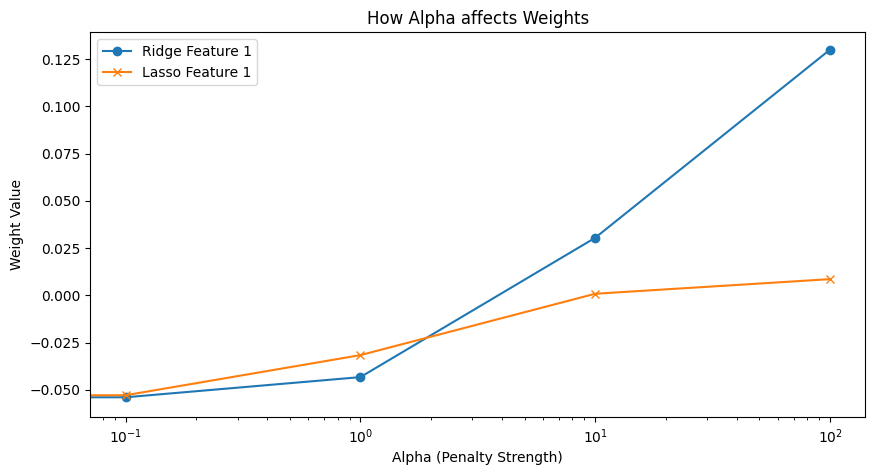

In [ ]:
alphas = [0, 0.1, 1, 10, 100]
ridge_weights = []
lasso_weights = []

for a in alphas:
    # Train Ridge
    r_model = RegularizedRegression(alpha=a, method='ridge')
    r_model.fit(X_train_final, y_train)
    ridge_weights.append(r_model.weights.flatten())

    # Train Lasso
    l_model = RegularizedRegression(alpha=a, method='lasso')
    l_model.fit(X_train_final, y_train)
    lasso_weights.append(l_model.weights.flatten())

# Plotting the behavior of the first feature weight
plt.figure(figsize=(10, 5))
plt.plot(alphas, [w[1] for w in ridge_weights], label='Ridge Feature 1', marker='o')
plt.plot(alphas, [w[1] for w in lasso_weights], label='Lasso Feature 1', marker='x')
plt.xscale('log')
plt.xlabel('Alpha (Penalty Strength)')
plt.ylabel('Weight Value')
plt.title('How Alpha affects Weights')
plt.legend()
plt.show()

Visualization

 *1. Preprocessing: We scaled everything because if we didn't, the model might penalize "Petal Length" more than "Petal Width" simply because its raw numbers are larger, which isn't fair.*

*2. The Class: We modified the fit method. Instead of just following the direction that reduces error, the model now has to balance "reducing error" vs. "keeping weights small."*

*3. The Result: Ridge is smooth. It says, "I'll keep all your sensors, but I'll turn their volume down so the noise doesn't overwhelm the prediction."*

*Lasso is aggressive. It says, "These two sensors are redundant; I'm setting their weights to exactly zero and ignoring them entirely."*